In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_gaussian_quantiles

In [2]:
def linear(seed=42):
    """生成线性可分数据"""
    np.random.seed(seed)
    X = np.random.uniform(-1, 1, (200, 2))
    y = np.where(X[:, 1] > 0.5*X[:, 0], 1, -1)
    return X, y

def nolinear(seed=42):
    """生成线性不可分数据"""
    np.random.seed(seed)
    X = np.random.uniform(-1, 1, (200, 2))
    y = np.where(X[:, 1] > 0.5*X[:, 0] + 0.3*np.sin(3*np.pi*X[:, 0]), 1, -1)
    return X, y

def gauss_linear(seed=42):
    """生成高斯分布线性可分数据"""
    return make_gaussian_quantiles(n_samples=200, n_features=2, 
                                  n_classes=2, random_state=seed)

def gauss_nolinear(seed=42):
    """生成高斯分布线性不可分数据"""
    X, y = make_gaussian_quantiles(n_samples=200, n_features=2, 
                                  n_classes=2, random_state=seed)
    y = np.where(X[:, 1] > 0.5*X[:, 0] + 0.3*np.sin(3*np.pi*X[:, 0]), 1, -1)
    return X, y

def circle(seed=42):
    """生成环形数据"""
    np.random.seed(seed)
    theta = np.random.uniform(0, 2*np.pi, 200)
    r = np.random.normal(1, 0.1, 200)
    X1 = np.vstack([r*np.cos(theta), r*np.sin(theta)]).T
    
    r = np.random.normal(3, 0.2, 200)
    X2 = np.vstack([r*np.cos(theta), r*np.sin(theta)]).T
    
    X = np.vstack([X1, X2])
    y = np.hstack([np.ones(200), -np.ones(200)])
    return X, y


def plot_decision_boundary(clf, X, y, title):
    """绘制分类界面"""
    xx, yy = np.meshgrid(np.linspace(X[:,0].min()-1, X[:,0].max()+1, 500),
                         np.linspace(X[:,1].min()-1, X[:,1].max()+1, 500))
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, levels=[-1, 0, 1], alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.Paired, edgecolors='k')
    plt.title(title)
    plt.show()

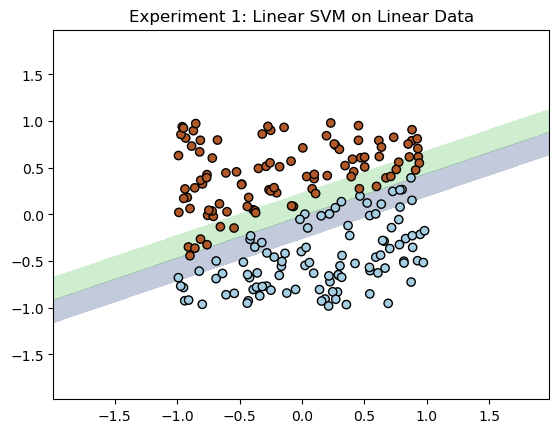

In [3]:
# 实验1：线性可分数据 + 线性SVM
X, y = linear()
clf = svm.SVC(kernel='linear').fit(X, y)
plot_decision_boundary(clf, X, y, "Experiment 1: Linear SVM on Linear Data")

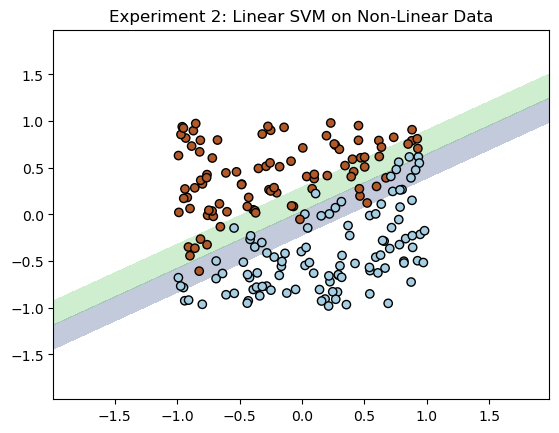

In [4]:
# 实验2：线性不可分数据 + 线性SVM
X, y = nolinear()
clf = svm.SVC(kernel='linear').fit(X, y)
plot_decision_boundary(clf, X, y, "Experiment 2: Linear SVM on Non-Linear Data")

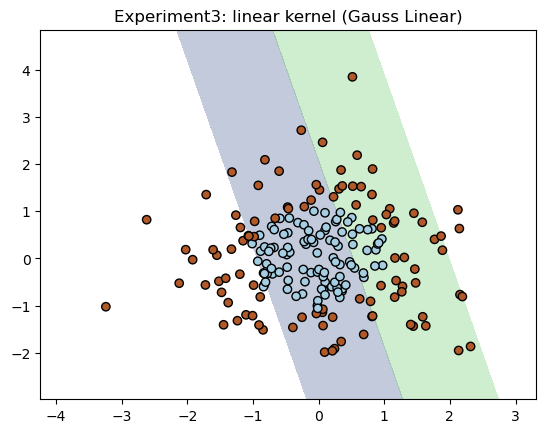

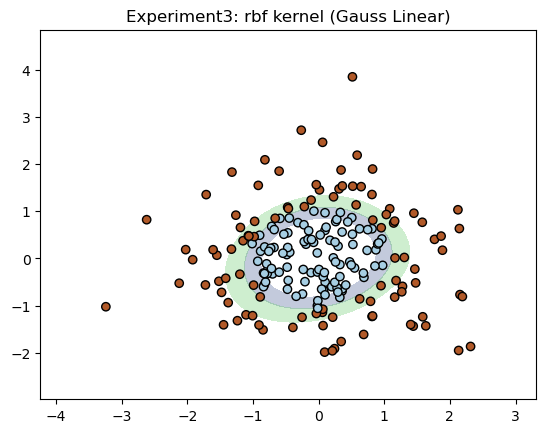

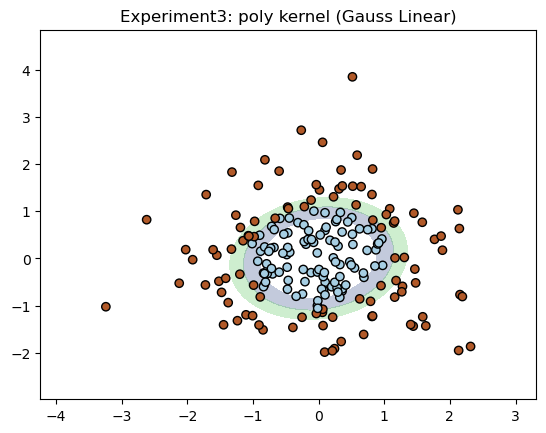

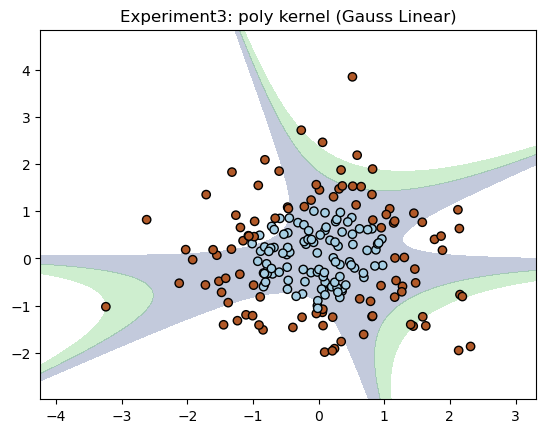

In [5]:
# 实验3：高斯线性可分数据 + 不同核
X, y = gauss_linear()
kernels = [('linear', {}), 
            ('rbf', {'gamma': 'scale'}), 
            ('poly', {'degree': 2}), 
            ('poly', {'degree': 3})]

for k_type, params in kernels:
    clf = svm.SVC(kernel=k_type, **params).fit(X, y)
    plot_decision_boundary(clf, X, y, 
                            f"Experiment3: {k_type} kernel (Gauss Linear)")

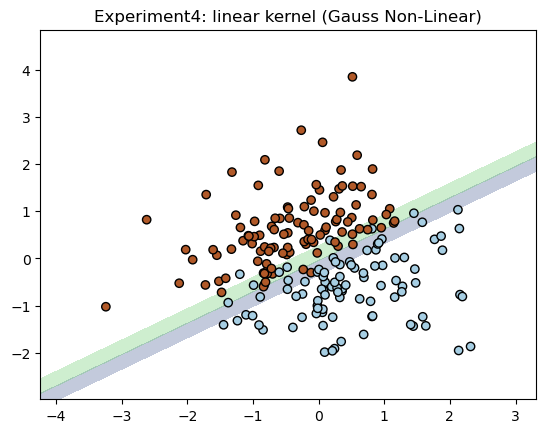

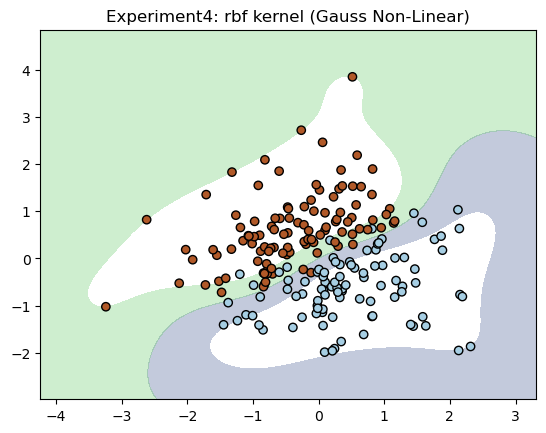

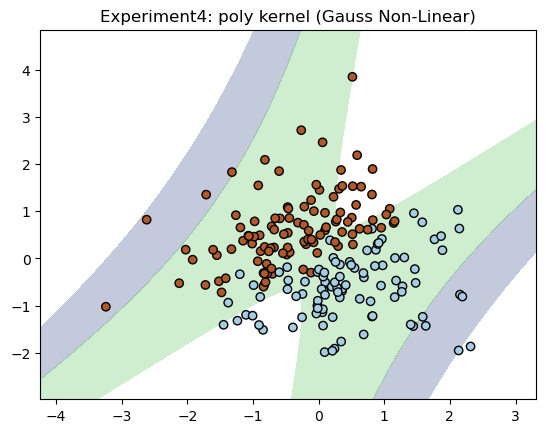

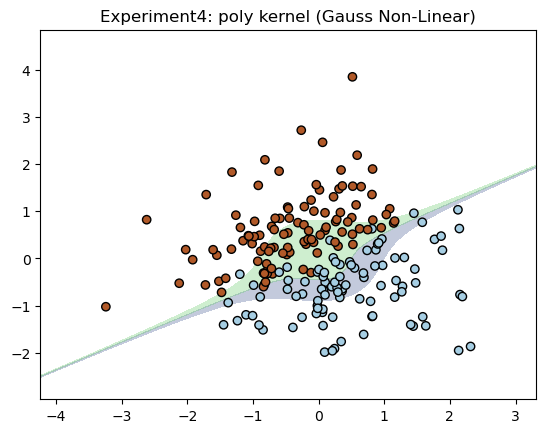

In [6]:
# 实验4：高斯非线性数据 + 不同核
X, y = gauss_nolinear()
for k_type, params in kernels:
    clf = svm.SVC(kernel=k_type, **params).fit(X, y)
    plot_decision_boundary(clf, X, y,
                            f"Experiment4: {k_type} kernel (Gauss Non-Linear)")

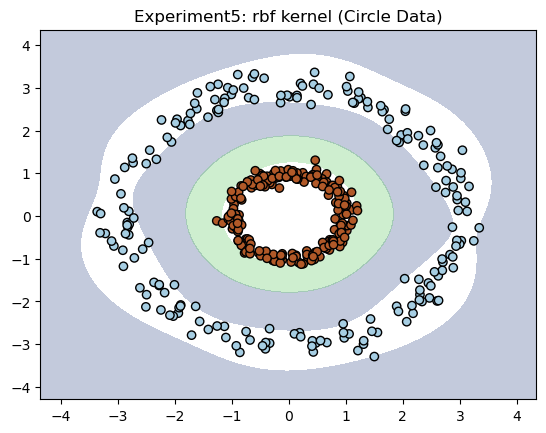

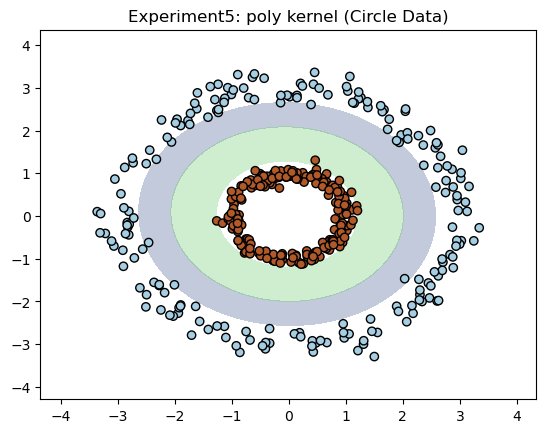

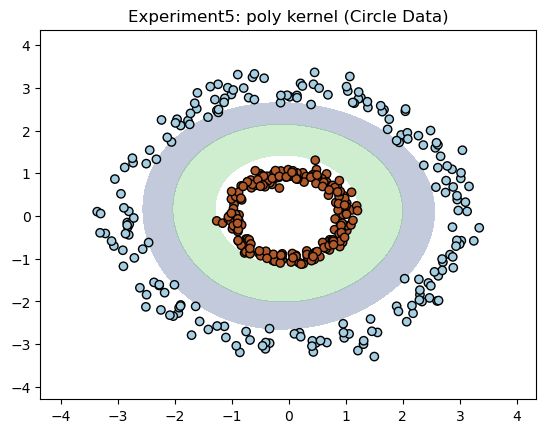

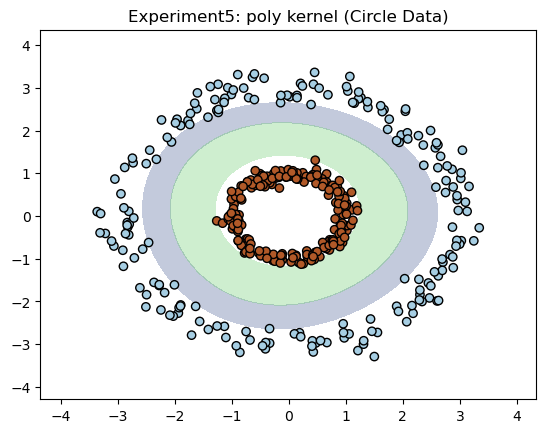

In [7]:
# 实验5：环形数据 + 不同核
X, y = circle()
circle_kernels = [('rbf', {'gamma': 0.5}),  # 调优gamma参数
                    ('poly', {'degree': 2, 'coef0': 1}),
                    ('poly', {'degree': 3, 'coef0': 1}),
                    ('poly', {'degree': 4, 'coef0': 1})]

for k_type, params in circle_kernels:
    clf = svm.SVC(kernel=k_type, **params).fit(X, y)
    plot_decision_boundary(clf, X, y,
                            f"Experiment5: {k_type} kernel (Circle Data)")